# **Decripcion del Dataset**
### **Predicción del Riesgo de Reingreso Hospitalario - Dataset**

**Descripción:**

Este conjunto de datos reúne información clínica, demográfica y hospitalaria de pacientes con el objetivo de predecir el riesgo de reingreso hospitalario dentro de los 30 días posteriores al alta médica. Su propósito es identificar patrones asociados a pacientes con mayor probabilidad de volver a ser hospitalizados, utilizando variables relacionadas con su historial médico, resultados de laboratorio, tratamientos recibidos y antecedentes de hospitalización.

**Fuente:** Kaggle: [agregar enlace del dataset]

Cada fila representa a un paciente atendido en un contexto hospitalario e incluye información sobre sus características personales, diagnóstico médico, tipo de ingreso, duración de la hospitalización, resultados de pruebas clínicas, medicamentos utilizados y antecedentes de visitas médicas previas.

**Variables principales:**

* ID del paciente
* Edad
* Género
* Etnia
* Estado civil
* Código postal
* Diagnóstico principal
* Diagnóstico secundario
* Presencia de enfermedad crónica
* Puntaje de comorbilidad
* Diabetes
* Hipertensión
* Enfermedad cardíaca
* Tipo de ingreso hospitalario
* Fuente de admisión
* Tipo de alta médica
* Duración de la hospitalización
* Número de hospitalizaciones previas
* Visitas a urgencias en el último año
* Consultas ambulatorias en el último año
* Nivel de glucosa en sangre
* Resultado de HbA1c
* Presión arterial sistólica y diastólica
* Nivel de hemoglobina
* Nivel de creatinina
* Cantidad de procedimientos de laboratorio
* Resultados de laboratorio anormales
* Número de medicamentos recetados
* Uso de insulina
* Cambio de medicación
* Número de procedimientos médicos
* Polifarmacia
* Reingreso hospitalario dentro de 30 días (`readmitted`)

Estos datos permiten analizar factores asociados al reingreso hospitalario, identificar pacientes de alto riesgo y construir modelos predictivos que apoyen la toma de decisiones clínicas. Además, pueden contribuir a mejorar la planificación del alta médica, optimizar el seguimiento posterior del paciente y reducir reingresos hospitalarios evitables.

La variable objetivo del conjunto de datos es **`readmitted`**, donde **1** indica que el paciente fue readmitido dentro de los 30 días posteriores al alta, y **0** indica que no fue readmitido.

El conjunto de datos contiene información relacionada con pacientes hospitalarios, diagnósticos, tratamientos y resultados clínicos. Para completar la descripción con precisión, se debe verificar la cantidad exacta de filas y columnas mediante Python.




### **Importación de Librerías**

In [2]:
# Importamos pandas para el manejo de tablas (DataFrames)
import pandas as pd

# Importamos numpy para operaciones matemáticas y manejo de valores nulos
import numpy as np

# Importamos matplotlib y seaborn para las visualizaciones y gráficos
import matplotlib.pyplot as plt
import seaborn as sns

import warnings
warnings.filterwarnings('ignore')

# Configurar el estilo de los gráficos
sns.set_theme(style="whitegrid")

### **Carga del Conjunto de Datos**

In [4]:
# Cargamos el dataset indicando el nombre exacto del archivo
df = pd.read_csv('C:/Users/yuril/OneDrive/Escritorio/Proyectos skillnest cientifico de datos/Proyecto 2 – Parte I (Core)/dataset/hospital_readmission_risk_dataset_2026_v1.csv')

# Primeros 5 registros del conjunto de datos
df.head()

,Age,Gender,Insurance_Type,Socioeconomic_Risk_Score,Previous_Admissions_6M,Previous_Readmissions_1Y,Time_Since_Last_Discharge,Length_of_Stay,Admission_Type,Primary_Diagnosis_Group,...,Creatinine_Level,Hemoglobin_Level,Average_Systolic_BP,Number_of_Medications,Medication_Change_Count,High_Risk_Medication_Flag,Followup_Appointment_Scheduled,Discharge_Disposition,Medication_Adherence_Score,Readmitted_Within_30_Days
0,71,Male,Medicare,9,2,0,96,15,Urgent,Infection,...,1.18,10.07,104,5,4,0,0,Rehab,0.54,1
1,34,Female,Private,8,4,0,58,12,Urgent,Infection,...,1.01,13.81,179,6,4,1,1,Rehab,0.42,1
2,80,Male,Medicare,2,1,3,25,11,Urgent,Respiratory,...,1.26,13.25,140,11,4,0,1,Home,0.97,1
3,40,Female,Private,7,2,0,42,2,Elective,Cardiac,...,0.57,15.46,131,9,3,0,1,Rehab,0.95,1
4,43,Male,Medicaid,5,2,1,176,3,Elective,Infection,...,1.05,8.33,171,6,3,0,1,Nursing Facility,0.64,0


### **Dimensiones del Dataset**

In [5]:
# df.shape devuelve una tupla: (filas, columnas)
df.shape

(18000, 25)

In [6]:
filas, columnas = df.shape

print("Cantidad de filas:", filas)
print("Cantidad de columnas:", columnas)

#El dataset contiene 18.000 registros y 25 columnas. Cada fila representa un paciente o episodio hospitalario, mientras que las columnas describen características demográficas, clínicas, administrativas y la variable objetivo relacionada con la readmisión hospitalaria dentro de 30 días.

Cantidad de filas: 18000
Cantidad de columnas: 25


### **Tipos de Datos y Estructura Básica**

In [7]:
# Muestra un resumen del tipo de datos por columna y la memoria utilizada
df.info()


<class 'pandas.DataFrame'>
RangeIndex: 18000 entries, 0 to 17999
Data columns (total 25 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   Age                             18000 non-null  int64  
 1   Gender                          18000 non-null  str    
 2   Insurance_Type                  18000 non-null  str    
 3   Socioeconomic_Risk_Score        18000 non-null  int64  
 4   Previous_Admissions_6M          18000 non-null  int64  
 5   Previous_Readmissions_1Y        18000 non-null  int64  
 6   Time_Since_Last_Discharge       18000 non-null  int64  
 7   Length_of_Stay                  18000 non-null  int64  
 8   Admission_Type                  18000 non-null  str    
 9   Primary_Diagnosis_Group         18000 non-null  str    
 10  Comorbidity_Index               18000 non-null  int64  
 11  Chronic_Disease_Count           18000 non-null  int64  
 12  ICU_Stay_Flag                   18000 non-n

El dataset contiene variables numéricas y categóricas. 
Las variables numéricas incluyen edad, puntaje socioeconómico, cantidad de admisiones previas, readmisiones previas, duración de la estadía hospitalaria, índice de comorbilidad, puntaje de severidad, resultados clínicos y cantidad de medicamentos.

Las variables categóricas incluyen género, tipo de seguro, tipo de admisión, grupo de diagnóstico principal y disposición al alta.

#### **Revision nombres de columnas**

In [8]:
df.columns
#Se revisan los nombres de las columnas para identificar las variables disponibles en el dataset.


Index(['Age', 'Gender', 'Insurance_Type', 'Socioeconomic_Risk_Score',
       'Previous_Admissions_6M', 'Previous_Readmissions_1Y',
       'Time_Since_Last_Discharge', 'Length_of_Stay', 'Admission_Type',
       'Primary_Diagnosis_Group', 'Comorbidity_Index', 'Chronic_Disease_Count',
       'ICU_Stay_Flag', 'Severity_Score', 'HbA1c_Level', 'Creatinine_Level',
       'Hemoglobin_Level', 'Average_Systolic_BP', 'Number_of_Medications',
       'Medication_Change_Count', 'High_Risk_Medication_Flag',
       'Followup_Appointment_Scheduled', 'Discharge_Disposition',
       'Medication_Adherence_Score', 'Readmitted_Within_30_Days'],
      dtype='str')

#### **Separacion de variables numéricas y categóricas**

In [9]:
columnas_numericas = df.select_dtypes(include=np.number).columns
columnas_categoricas = df.select_dtypes(include="object").columns

print("Variables numéricas:")
print(columnas_numericas)

print("Variables categóricas:")
print(columnas_categoricas)

Variables numéricas:
Index(['Age', 'Socioeconomic_Risk_Score', 'Previous_Admissions_6M',
       'Previous_Readmissions_1Y', 'Time_Since_Last_Discharge',
       'Length_of_Stay', 'Comorbidity_Index', 'Chronic_Disease_Count',
       'ICU_Stay_Flag', 'Severity_Score', 'HbA1c_Level', 'Creatinine_Level',
       'Hemoglobin_Level', 'Average_Systolic_BP', 'Number_of_Medications',
       'Medication_Change_Count', 'High_Risk_Medication_Flag',
       'Followup_Appointment_Scheduled', 'Medication_Adherence_Score',
       'Readmitted_Within_30_Days'],
      dtype='str')
Variables categóricas:
Index(['Gender', 'Insurance_Type', 'Admission_Type', 'Primary_Diagnosis_Group',
       'Discharge_Disposition'],
      dtype='str')


Se separan las variables numéricas y categóricas para facilitar el análisis. 
Las variables numéricas serán utilizadas para estadísticas descriptivas, histogramas, boxplots y correlaciones. 
Las variables categóricas serán analizadas mediante frecuencias y gráficos de barras.

### **Análisis Estadístico Descriptivo**

### **Variables Numéricas**

In [10]:
# Estadísticas descriptivas para variables numéricas
df.describe().T


,count,mean,std,min,25%,50%,75%,max
Age,18000.0,54.504889,20.206770,20.00,37.00,54.00,72.00,89.00
Socioeconomic_Risk_Score,18000.0,5.006889,2.582783,1.00,3.00,5.00,7.00,9.00
Previous_Admissions_6M,18000.0,1.503944,1.225543,0.00,1.00,1.00,2.00,8.00
Previous_Readmissions_1Y,18000.0,0.999667,1.004518,0.00,0.00,1.00,2.00,7.00
Time_Since_Last_Discharge,18000.0,90.245889,51.882074,1.00,45.00,91.00,135.00,179.00
Length_of_Stay,18000.0,10.049444,5.455903,1.00,5.00,10.00,15.00,19.00
Comorbidity_Index,18000.0,2.475556,1.703104,0.00,1.00,2.00,4.00,5.00
Chronic_Disease_Count,18000.0,1.991222,1.413951,0.00,1.00,2.00,3.00,4.00
ICU_Stay_Flag,18000.0,0.197778,0.398335,0.00,0.00,0.00,0.00,1.00
Severity_Score,18000.0,5.005500,2.576422,1.00,3.00,5.00,7.00,9.00


El análisis descriptivo permite observar medidas como media, desviación estándar, valores mínimos, máximos y cuartiles. 
En este dataset, la edad promedio de los pacientes es cercana a 54 años. 
La duración promedio de la hospitalización es cercana a 10 días, mientras que el tiempo promedio desde el último alta médica es de aproximadamente 90 días.

También se observa que la variable `Readmitted_Within_30_Days` tiene una media cercana a 0.74, lo que indica que una proporción importante de pacientes fue readmitida dentro de los 30 días.

| Variable                     | Comentario                                            |
| ---------------------------- | ----------------------------------------------------- |
| `Age`                        | Edad entre 20 y 89 años, promedio cercano a 54 años.  |
| `Previous_Admissions_6M`     | Promedio cercano a 1.5 admisiones previas en 6 meses. |
| `Previous_Readmissions_1Y`   | Promedio cercano a 1 readmisión previa en 1 año.      |
| `Length_of_Stay`             | Promedio cercano a 10 días de hospitalización.        |
| `Severity_Score`             | Va de 1 a 9, con promedio cercano a 5.                |
| `Number_of_Medications`      | Promedio cercano a 7.5 medicamentos.                  |
| `Medication_Adherence_Score` | Promedio cercano a 0.70.                              |
| `Readmitted_Within_30_Days`  | Aproximadamente 74% de pacientes readmitidos.         |


### **Variables Categóricas**

In [11]:
# Distribución de variables categóricas
df.describe(include='object').T

,count,unique,top,freq
Gender,18000,2,Male,9086
Insurance_Type,18000,3,Medicare,6140
Admission_Type,18000,3,Urgent,6031
Primary_Diagnosis_Group,18000,5,Other,3708
Discharge_Disposition,18000,3,Home,6064


Las variables categóricas permiten conocer la distribución de los grupos dentro del dataset. 
En este caso se analizan variables como género, tipo de seguro, tipo de admisión, diagnóstico principal y disposición al alta.

#### **Revision valores variable categóricas**

In [13]:
# Revisamos los valores únicos y sus frecuencias
for col in columnas_categoricas:
    print("\nColumna:", col)
    print("Cantidad de valores únicos:", df[col].nunique())
    print(df[col].value_counts())


Columna: Gender
Cantidad de valores únicos: 2
Gender
Male      9086
Female    8914
Name: count, dtype: int64

Columna: Insurance_Type
Cantidad de valores únicos: 3
Insurance_Type
Medicare    6140
Medicaid    5999
Private     5861
Name: count, dtype: int64

Columna: Admission_Type
Cantidad de valores únicos: 3
Admission_Type
Urgent       6031
Emergency    5989
Elective     5980
Name: count, dtype: int64

Columna: Primary_Diagnosis_Group
Cantidad de valores únicos: 5
Primary_Diagnosis_Group
Other          3708
Infection      3615
Diabetes       3590
Respiratory    3551
Cardiac        3536
Name: count, dtype: int64

Columna: Discharge_Disposition
Cantidad de valores únicos: 3
Discharge_Disposition
Home                6064
Nursing Facility    5990
Rehab               5946
Name: count, dtype: int64


Se revisan los valores únicos de cada variable categórica para detectar posibles errores de escritura, categorías duplicadas, valores extraños o categorías poco frecuentes.
No se observan incongruencias evidentes en las variables categóricas. 
Las categorías están escritas de forma consistente y no se detectan errores como espacios extra, nombres duplicados o valores mal escritos.

### **Detección y Corrección de Incongruencias Categóricas**
Se realizó una auditoría de las principales variables categóricas del dataset con el objetivo de identificar posibles inconsistencias en los valores.

Este proceso permite revisar si existen categorías repetidas con diferencias de escritura, uso de mayúsculas o minúsculas, espacios adicionales o valores mal registrados.

Esta revisión es importante porque las variables categóricas deben estar correctamente estandarizadas antes de realizar análisis más profundos o aplicar modelos de machine learning.

In [15]:
# Le decimos a pandas que no recorte el contenido de las columnas
pd.set_option("display.max_colwidth", None)

# Definimos las columnas categóricas que queremos analizar
columnas_objetivo = [
    "Gender",
    "Insurance_Type",
    "Admission_Type",
    "Primary_Diagnosis_Group",
    "Discharge_Disposition"
]

# Creamos una lista para guardar el diagnóstico
lista_resumen = []

for col in columnas_objetivo:
    if col in df.columns:
        cantidad_unicos = df[col].nunique(dropna=False)
        todos_los_valores = df[col].dropna().unique().tolist()
        
        lista_resumen.append({
            "Columna": col,
            "Cantidad de valores únicos": cantidad_unicos,
            "Valores encontrados": todos_los_valores
        })

# Convertimos la lista en DataFrame
resumen_categoricas = pd.DataFrame(lista_resumen)

resumen_categoricas

,Columna,Cantidad de valores únicos,Valores encontrados
0,Gender,2,"[Male, Female]"
1,Insurance_Type,3,"[Medicare, Private, Medicaid]"
2,Admission_Type,3,"[Urgent, Elective, Emergency]"
3,Primary_Diagnosis_Group,5,"[Infection, Respiratory, Cardiac, Other, Diabetes]"
4,Discharge_Disposition,3,"[Rehab, Home, Nursing Facility]"


Se realizó una revisión de incongruencias categóricas para verificar que las categorías estuvieran correctamente escritas. 
No se identificaron errores evidentes en las variables categóricas, por lo tanto no fue necesario realizar correcciones en esta etapa.

### **Identificación de Valores Nulos, Duplicados y Outliers**

#### **Detección de Valores Nulos**

In [16]:
# Revisamos la cantidad de valores nulos por columna
nulos = df.isnull().sum()

# Calculamos el porcentaje de valores nulos
porcentaje_nulos = df.isnull().mean() * 100

# Creamos una tabla resumen
tabla_nulos = pd.DataFrame({
    "Valores nulos": nulos,
    "Porcentaje (%)": porcentaje_nulos
})

tabla_nulos

,Valores nulos,Porcentaje (%)
Age,0,0.0
Gender,0,0.0
Insurance_Type,0,0.0
Socioeconomic_Risk_Score,0,0.0
Previous_Admissions_6M,0,0.0
Previous_Readmissions_1Y,0,0.0
Time_Since_Last_Discharge,0,0.0
Length_of_Stay,0,0.0
Admission_Type,0,0.0
Primary_Diagnosis_Group,0,0.0


No se identifican valores nulos en el dataset. 
Esto es positivo, ya que no es necesario aplicar imputación de datos faltantes ni eliminar registros por ausencia de información..

#### **Identificando Duplicados**

In [17]:
# Identificación de registros duplicados
duplicados = df.duplicated().sum()

print(f"Registros duplicados encontrados: {duplicados}")

if duplicados > 0:
    display(df[df.duplicated()].head())

Registros duplicados encontrados: 0


No se encontraron registros duplicados en el dataset. 
Esto indica que cada fila representa un registro único y no es necesario eliminar observaciones repetidas.s.

### **Visualizaciones**

#### **Histogramas de variables numéricas**

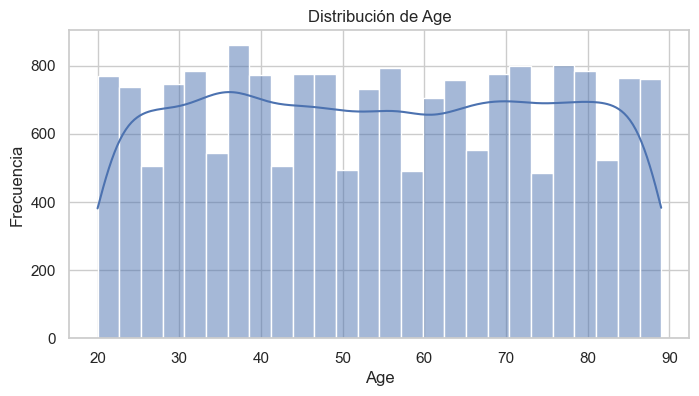

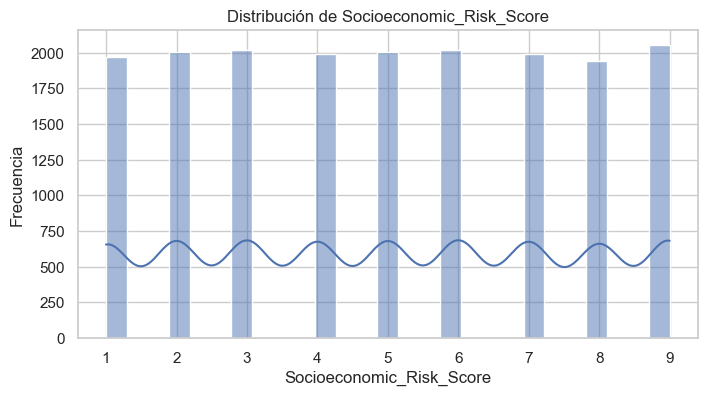

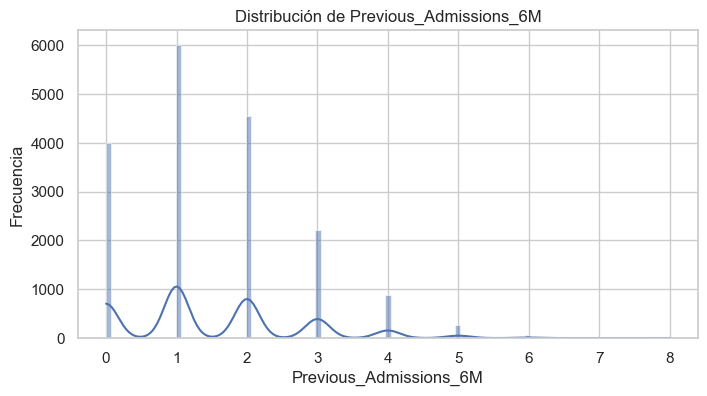

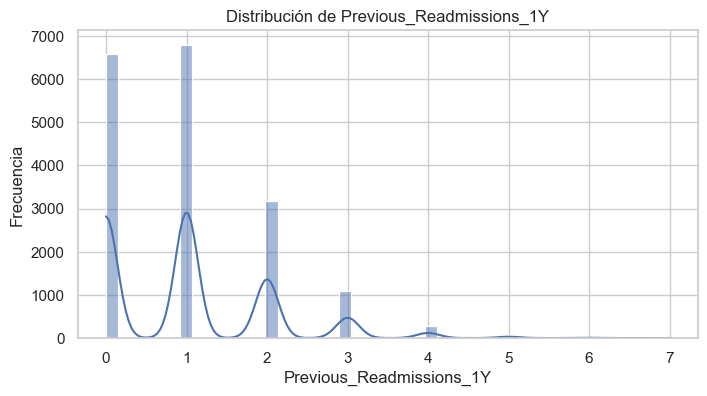

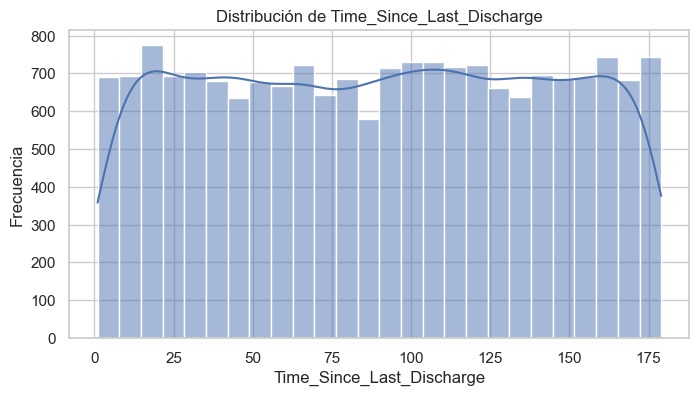

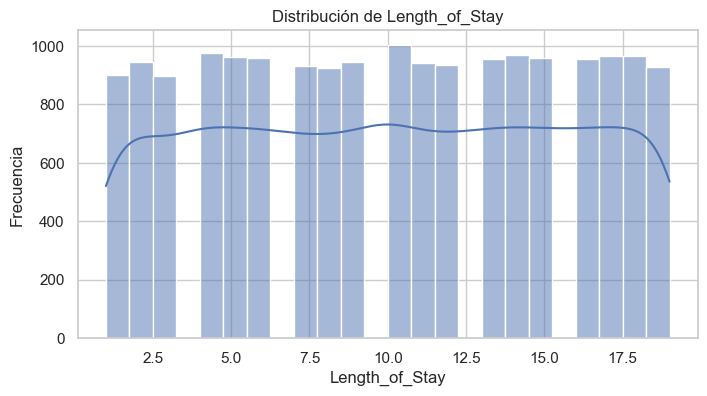

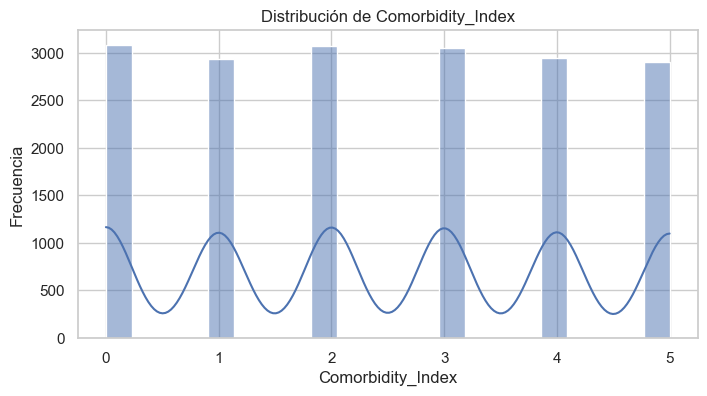

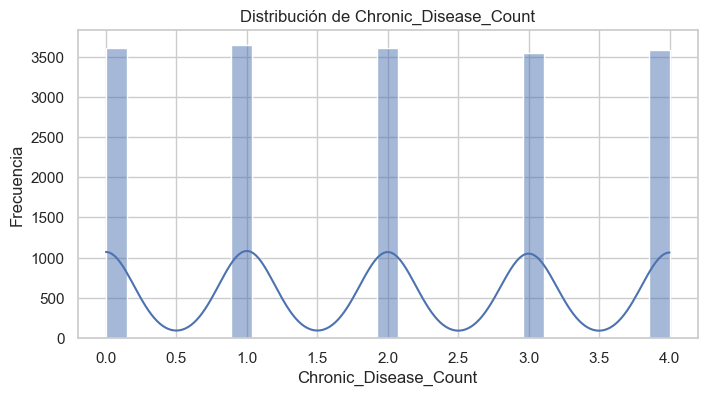

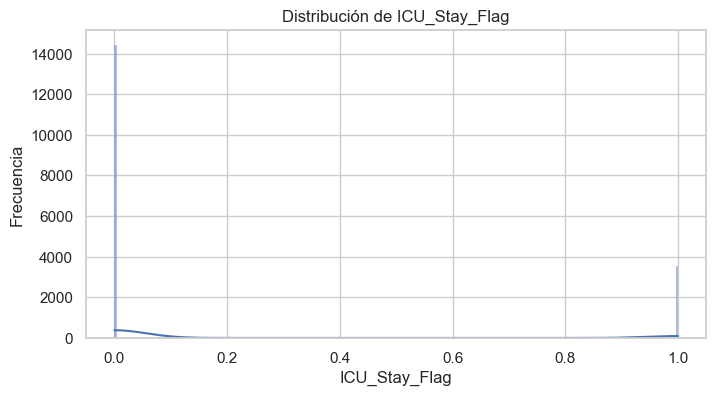

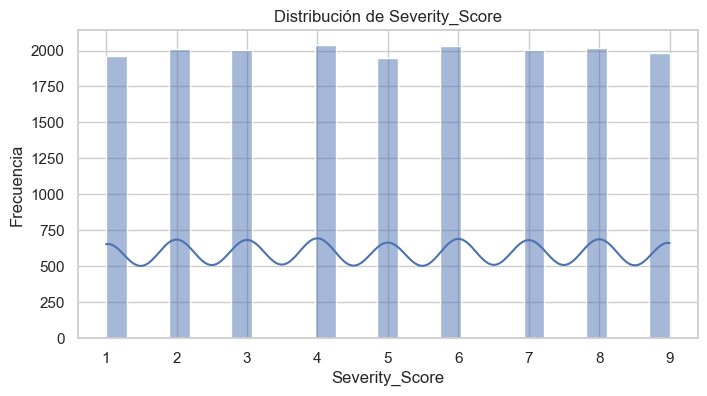

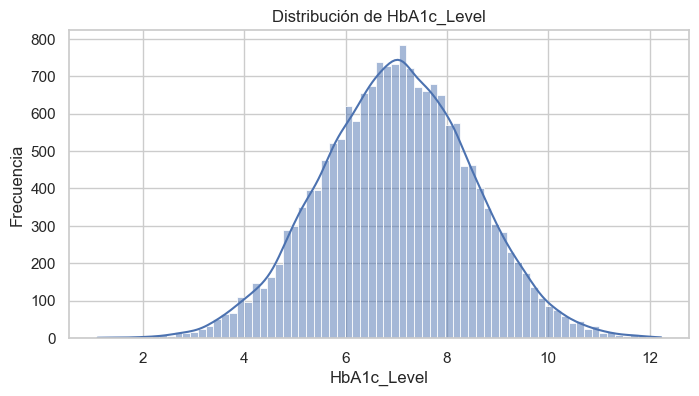

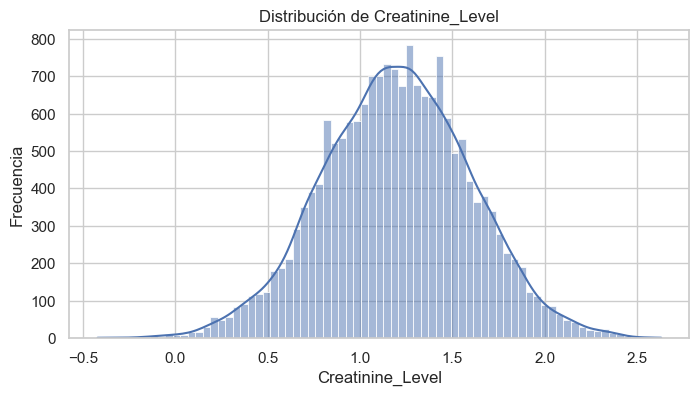

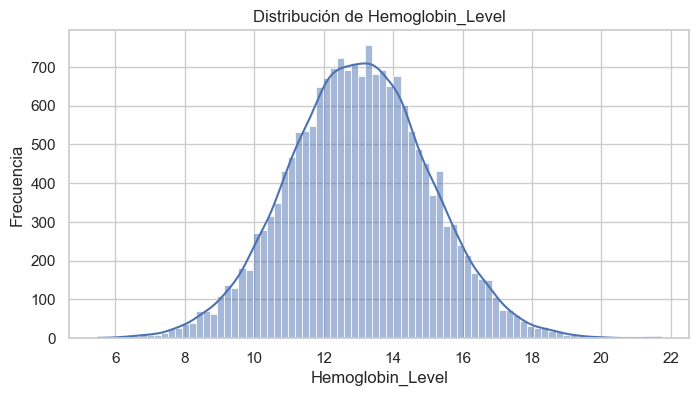

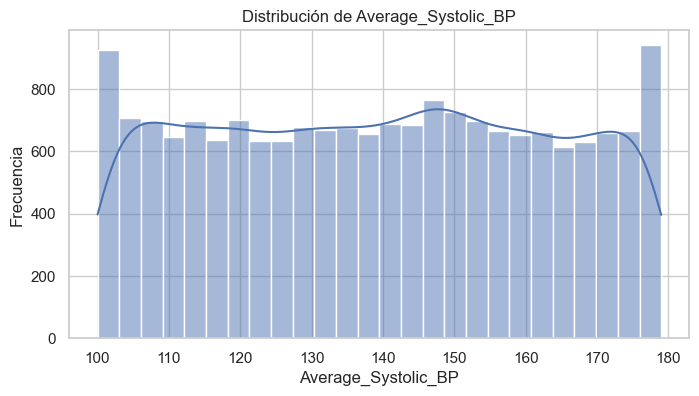

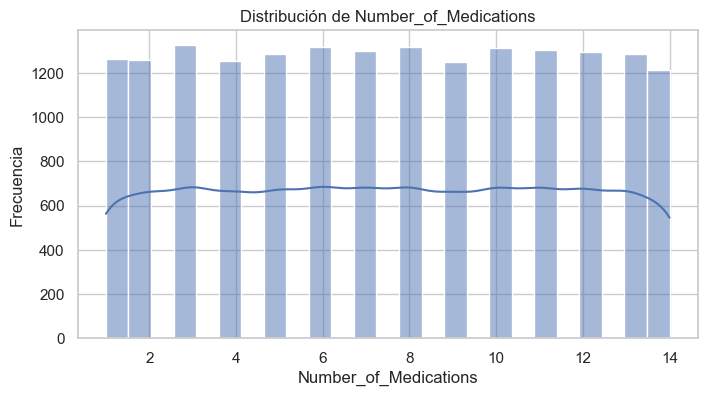

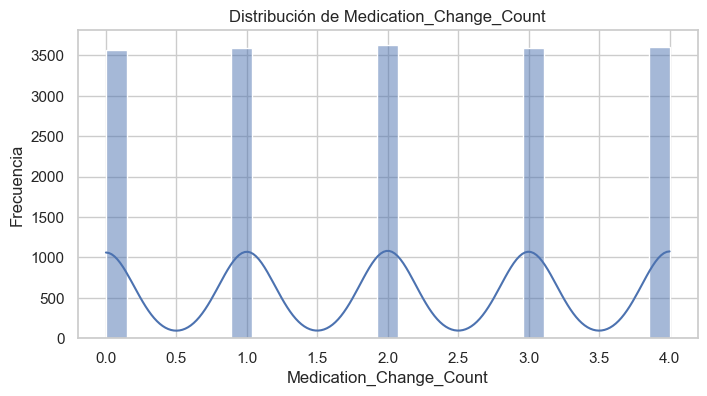

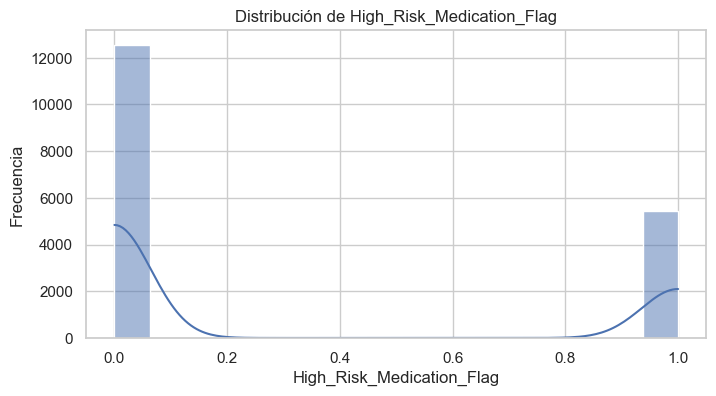

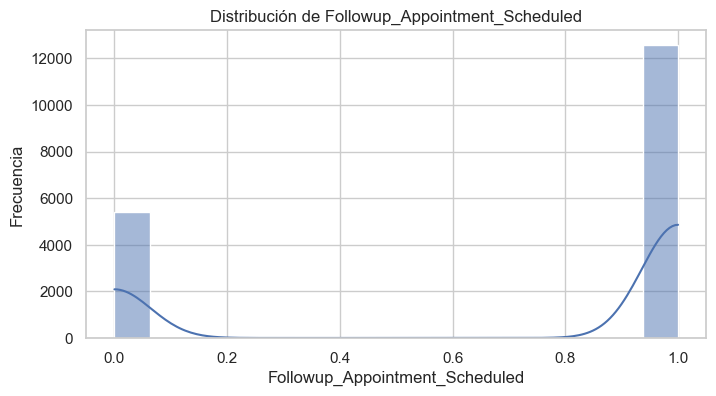

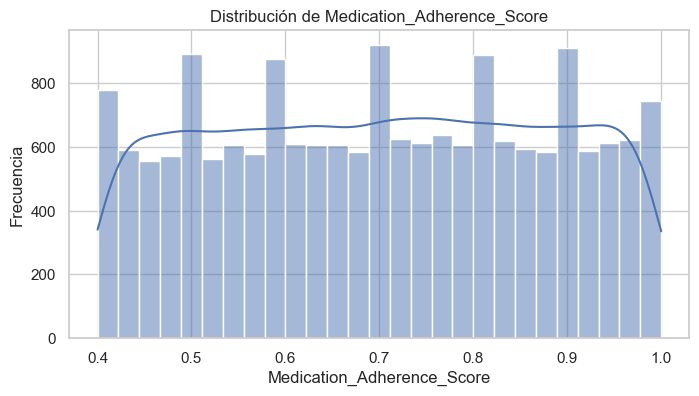

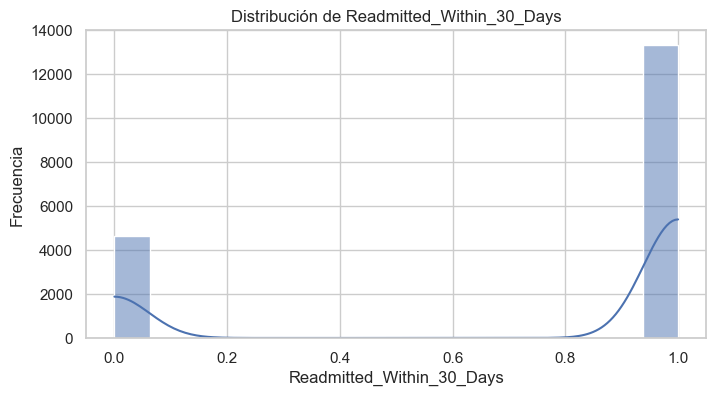

In [18]:
for col in columnas_numericas:
    plt.figure(figsize=(8, 4))
    sns.histplot(df[col], kde=True)
    plt.title(f"Distribución de {col}")
    plt.xlabel(col)
    plt.ylabel("Frecuencia")
    plt.show()

Los histogramas permiten observar la distribución de las variables numéricas. 
En general, varias variables presentan distribuciones relativamente equilibradas dentro de sus rangos, como edad, duración de la estadía hospitalaria y presión sistólica promedio.

Algunas variables son binarias, como `ICU_Stay_Flag`, `High_Risk_Medication_Flag`, `Followup_Appointment_Scheduled` y `Readmitted_Within_30_Days`, por lo que su distribución se interpreta mejor como conteo de categorías 0 y 1.

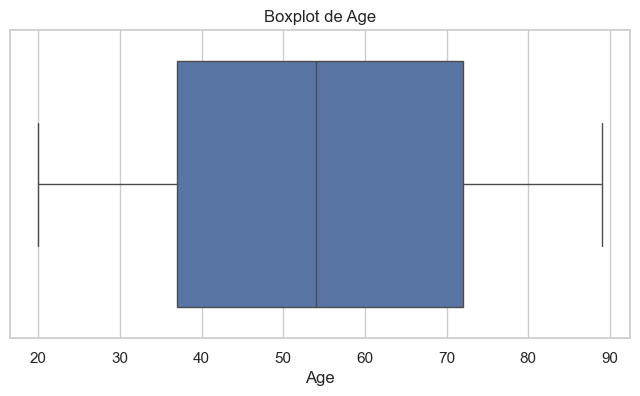

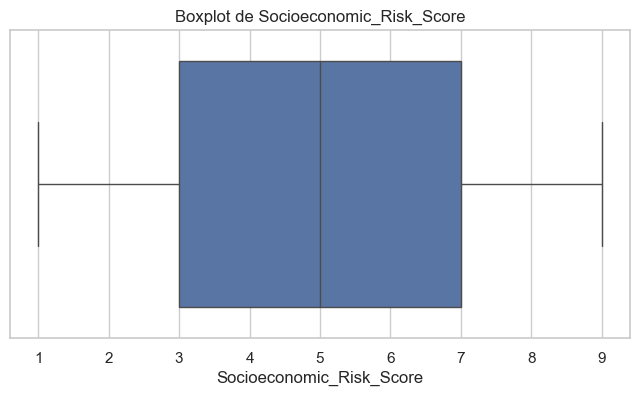

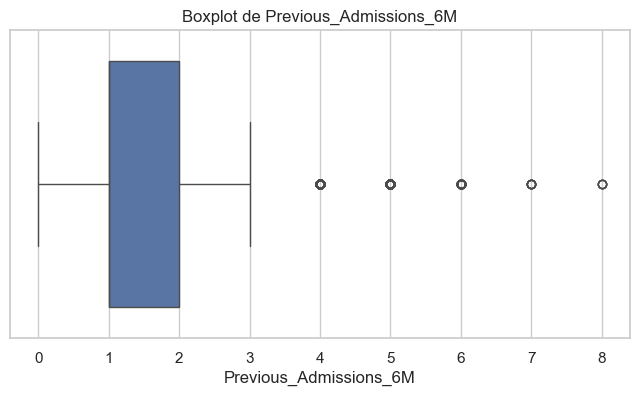

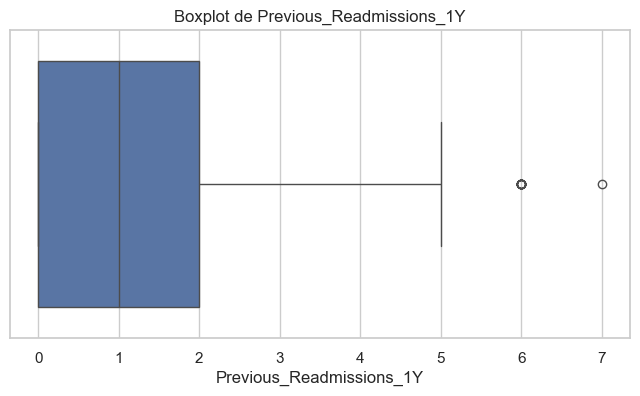

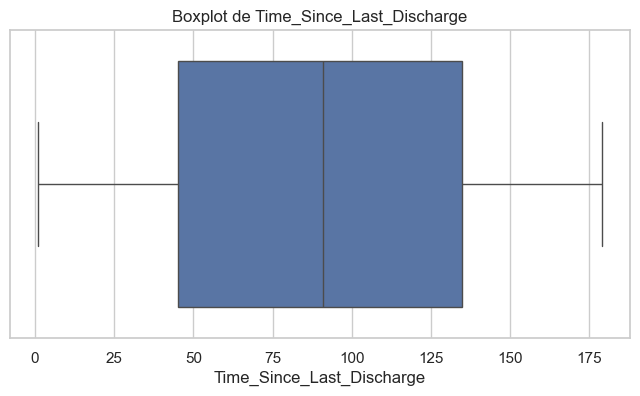

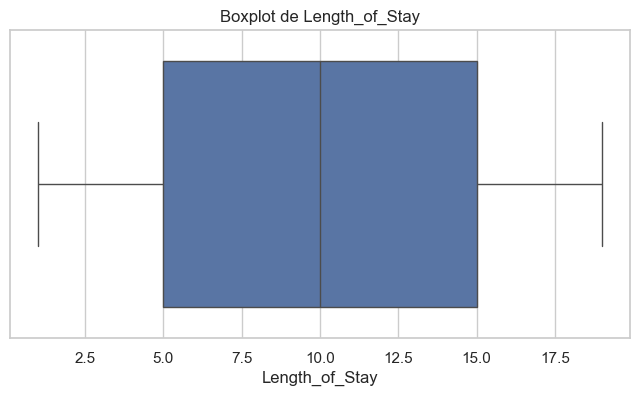

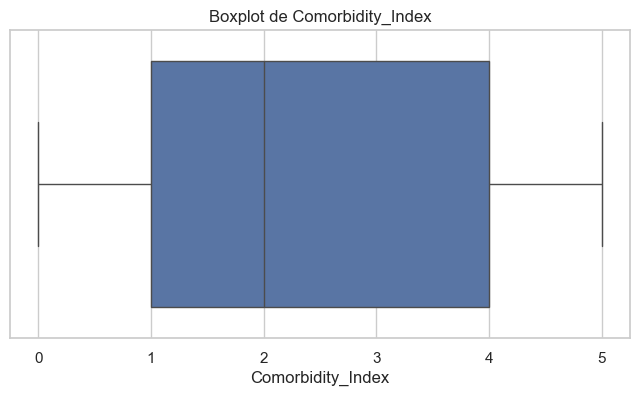

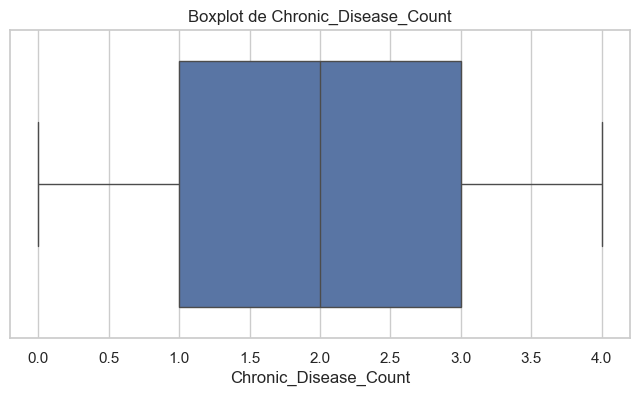

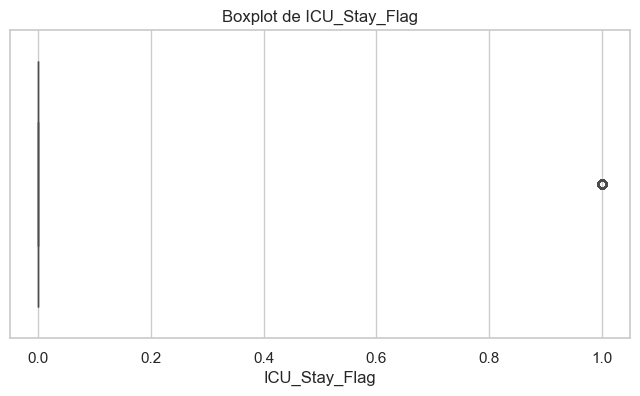

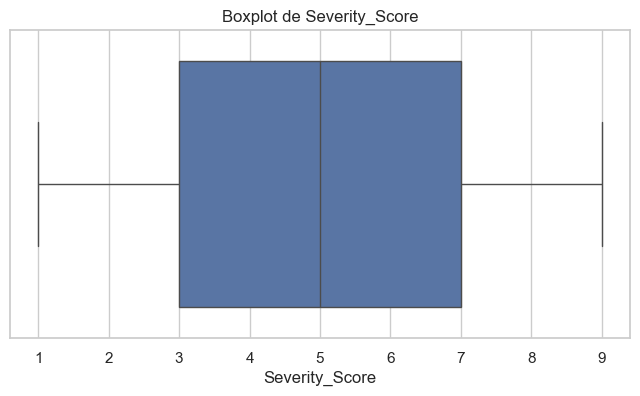

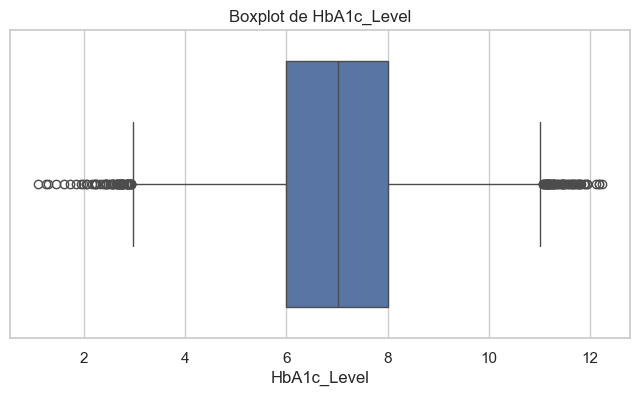

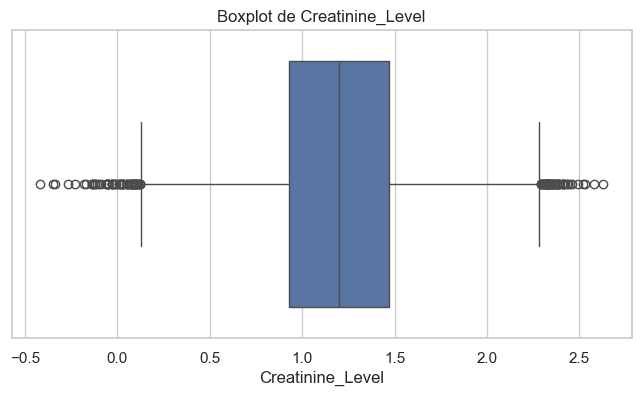

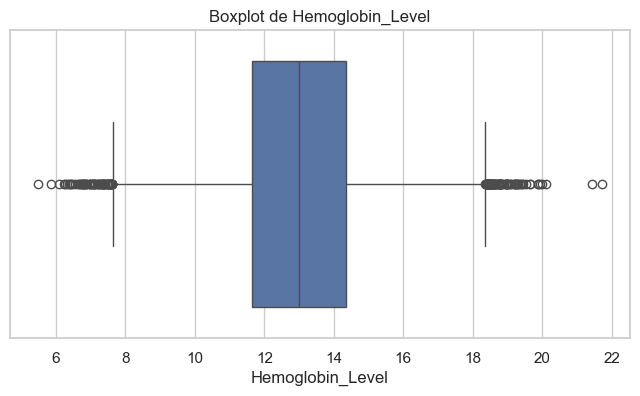

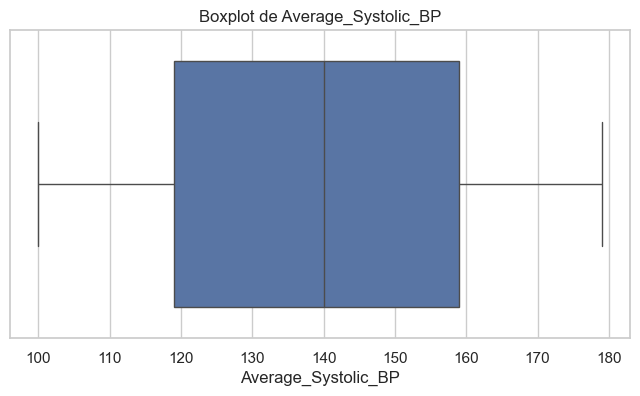

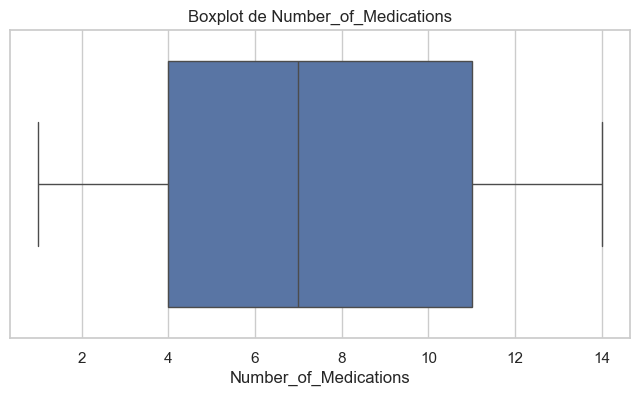

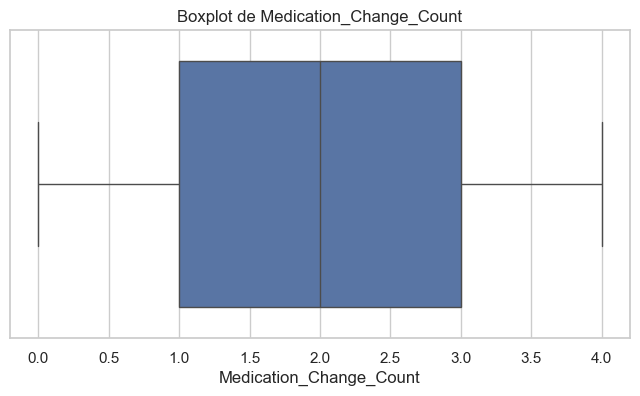

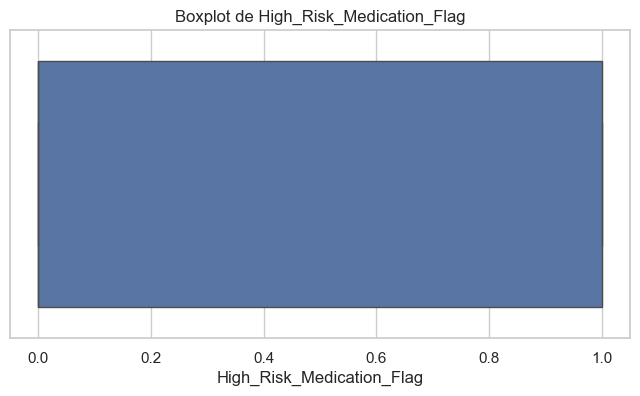

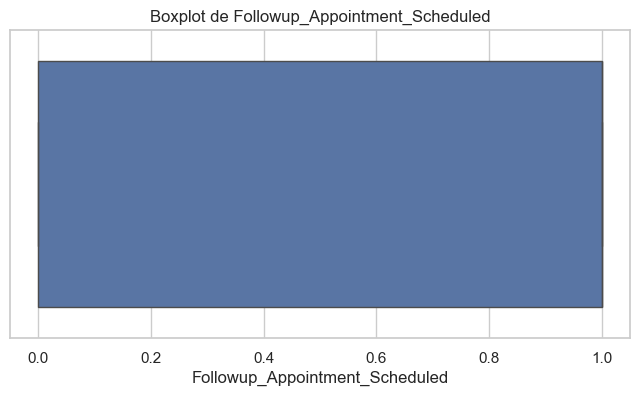

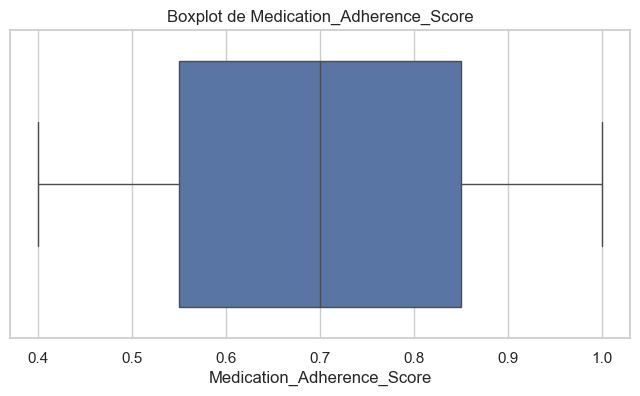

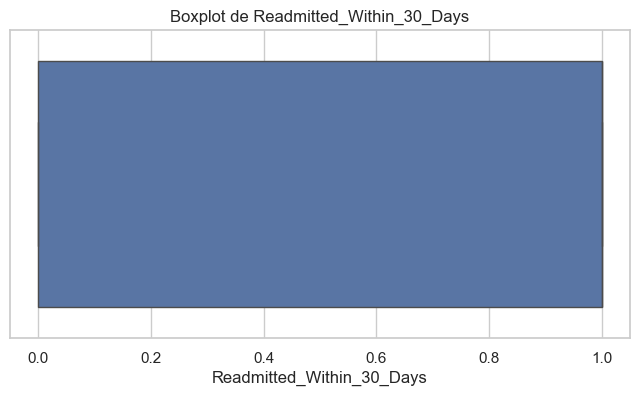

In [19]:
# Boxplots para revisar posibles outliers
for col in columnas_numericas:
    plt.figure(figsize=(8, 4))
    sns.boxplot(x=df[col])
    plt.title(f"Boxplot de {col}")
    plt.xlabel(col)
    plt.show()

Los boxplots permiten identificar visualmente posibles valores atípicos. 
En este dataset se observan posibles outliers en variables como `Previous_Admissions_6M`, `Previous_Readmissions_1Y`, `HbA1c_Level`, `Creatinine_Level` y `Hemoglobin_Level`.

Sin embargo, estos valores no deben eliminarse automáticamente, ya que en un contexto médico pueden representar pacientes con condiciones clínicas más complejas o casos de mayor riesgo.

### **Identificando Outliers**

La revisión de valores atípicos (outliers) es importante porque pueden distorsionar el análisis estadístico y afectar el rendimiento de algunos modelos de machine learning. Algoritmos como la regresión lineal, K-Means o KNN son especialmente sensibles a estos valores extremos, mientras que los modelos basados en árboles suelen ser más robustos. Por ello, es recomendable identificarlos y evaluar si corresponden a errores o a comportamientos reales de los datos.

In [20]:
# Detección de outliers usando el método del rango intercuartílico
resumen_outliers = []

for col in columnas_numericas:
    q1 = df[col].quantile(0.25)
    q3 = df[col].quantile(0.75)
    iqr = q3 - q1
    
    limite_inferior = q1 - 1.5 * iqr
    limite_superior = q3 + 1.5 * iqr
    
    outliers = df[(df[col] < limite_inferior) | (df[col] > limite_superior)]
    
    resumen_outliers.append({
        "Variable": col,
        "Límite inferior": limite_inferior,
        "Límite superior": limite_superior,
        "Cantidad de outliers": outliers.shape[0],
        "Porcentaje de outliers": round((outliers.shape[0] / df.shape[0]) * 100, 2)
    })

tabla_outliers = pd.DataFrame(resumen_outliers)

tabla_outliers

,Variable,Límite inferior,Límite superior,Cantidad de outliers,Porcentaje de outliers
0,Age,-15.50,124.50,0,0.00
1,Socioeconomic_Risk_Score,-3.00,13.00,0,0.00
2,Previous_Admissions_6M,-0.50,3.50,1222,6.79
3,Previous_Readmissions_1Y,-3.00,5.00,16,0.09
4,Time_Since_Last_Discharge,-90.00,270.00,0,0.00
5,Length_of_Stay,-10.00,30.00,0,0.00
6,Comorbidity_Index,-3.50,8.50,0,0.00
7,Chronic_Disease_Count,-2.00,6.00,0,0.00
8,ICU_Stay_Flag,0.00,0.00,3560,19.78
9,Severity_Score,-3.00,13.00,0,0.00


Se aplica el método IQR para detectar posibles outliers en las variables numéricas.

El IQR corresponde a la diferencia entre el tercer cuartil y el primer cuartil. A partir de este valor se calculan límites inferiores y superiores.

Los valores que quedan fuera de esos límites pueden considerarse posibles outliers.

Se identificaron posibles outliers en algunas variables numéricas. 
La variable `Previous_Admissions_6M` presenta una cantidad relevante de valores atípicos, lo que puede indicar pacientes con múltiples hospitalizaciones recientes. 
También aparecen outliers en variables clínicas como `HbA1c_Level`, `Creatinine_Level` y `Hemoglobin_Level`.

En el caso de variables binarias como `ICU_Stay_Flag`, el método IQR puede marcar valores como atípicos debido a que solo existen valores 0 y 1. 
Por esta razón, los outliers en variables binarias no deben interpretarse como errores.

| Variable                   | Outliers aproximados | Interpretación                            |
| -------------------------- | -------------------: | ----------------------------------------- |
| `Previous_Admissions_6M`   |                 1222 | Pacientes con varias admisiones recientes |
| `Previous_Readmissions_1Y` |                   16 | Casos con muchas readmisiones previas     |
| `ICU_Stay_Flag`            |                 3560 | No es error, es variable binaria          |
| `HbA1c_Level`              |                  126 | Valores clínicos extremos                 |
| `Creatinine_Level`         |                  130 | Posibles casos clínicos relevantes        |
| `Hemoglobin_Level`         |                  155 | Valores clínicos extremos                 |


#### **Gráficos de barras para variables categóricas**

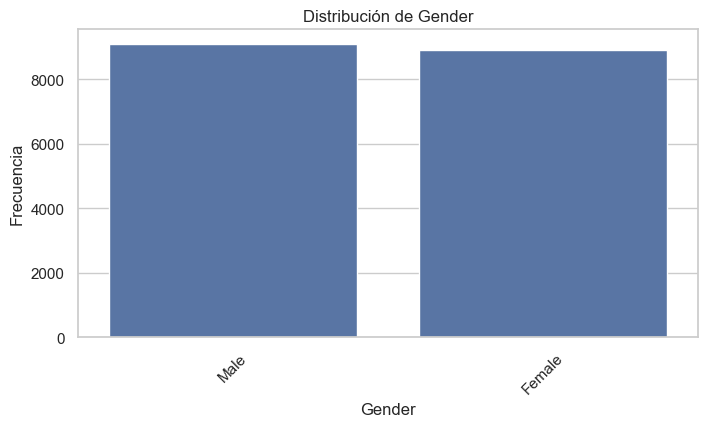

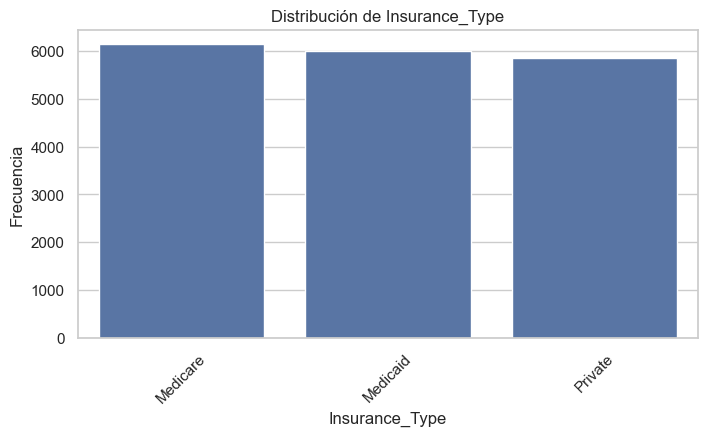

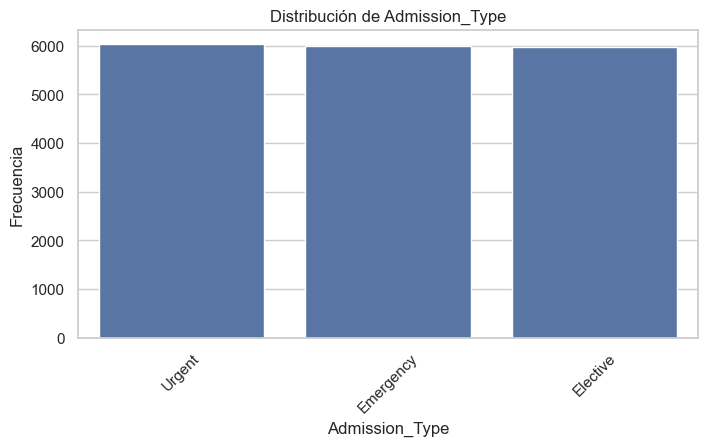

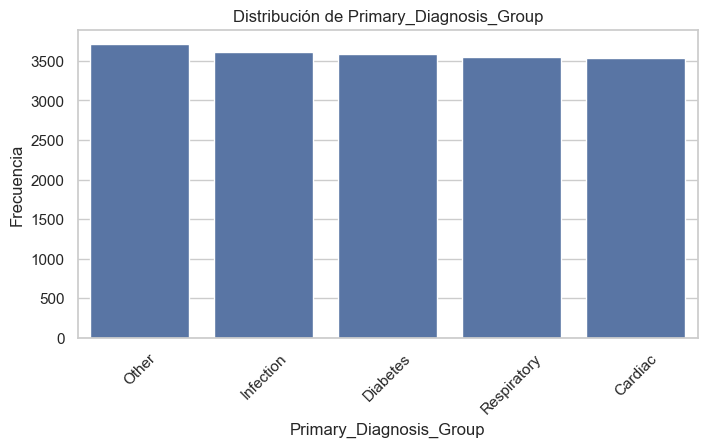

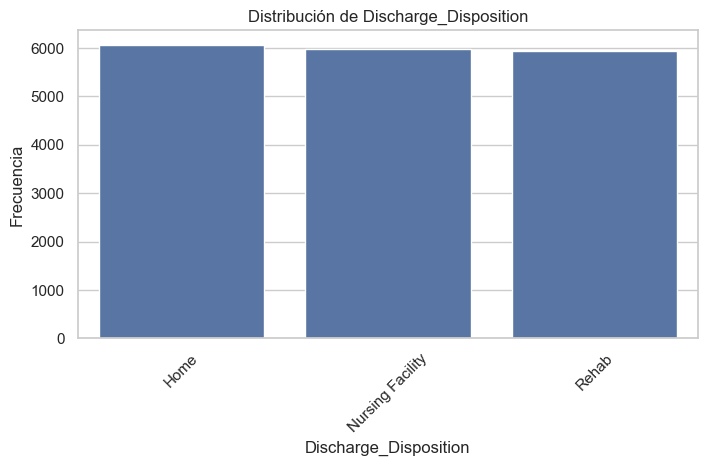

In [21]:
# Gráficos de barras para variables categóricas
for col in columnas_categoricas:
    plt.figure(figsize=(8, 4))
    sns.countplot(data=df,x=col,order=df[col].value_counts().index)
    plt.title(f"Distribución de {col}")
    plt.xlabel(col)
    plt.ylabel("Frecuencia")
    plt.xticks(rotation=45)
    plt.show()

Los gráficos de barras permiten observar la distribución de las variables categóricas. 
En este dataset, las categorías se encuentran bastante equilibradas. 
Por ejemplo, la variable `Gender` tiene una distribución similar entre hombres y mujeres. 
También se observa una distribución relativamente balanceada en tipo de seguro, tipo de admisión y disposición al alta.

### **Visualizaciones del Análisis Exploratorio**

#### **Distribución de la variable objetivo**

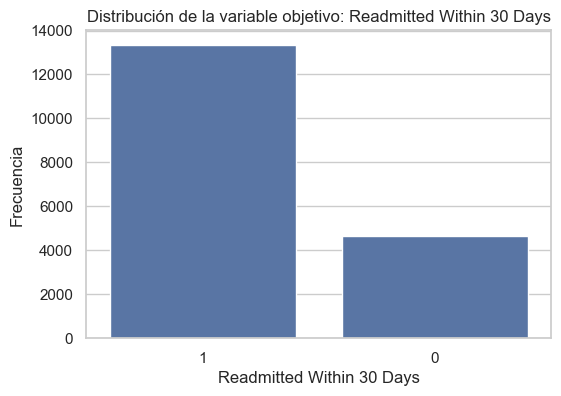

In [22]:
# Distribución de la variable objetivo
plt.figure(figsize=(6, 4))

sns.countplot(data=df,x="Readmitted_Within_30_Days",order=df["Readmitted_Within_30_Days"].value_counts().index)

plt.title("Distribución de la variable objetivo: Readmitted Within 30 Days")
plt.xlabel("Readmitted Within 30 Days")
plt.ylabel("Frecuencia")
plt.show()

In [23]:
# Porcentaje de cada clase
df["Readmitted_Within_30_Days"].value_counts(normalize=True) * 100

Readmitted_Within_30_Days
1    74.161111
0    25.838889
Name: proportion, dtype: float64

La variable objetivo `Readmitted_Within_30_Days` indica si el paciente fue readmitido dentro de los 30 días posteriores al alta médica.

El dataset presenta 13.349 pacientes readmitidos y 4.651 pacientes no readmitidos. 
Esto equivale aproximadamente a un 74,16% de pacientes readmitidos y un 25,84% de pacientes no readmitidos.

Existe un desbalance de clases, ya que la clase 1 es claramente mayoritaria. 
Este punto es importante porque, en una futura etapa de modelamiento, no bastará con mirar solo la exactitud del modelo. También será necesario revisar métricas como recall, precision, F1-score y matriz de confusión.

#### **Mapa de calor de correlaciones**

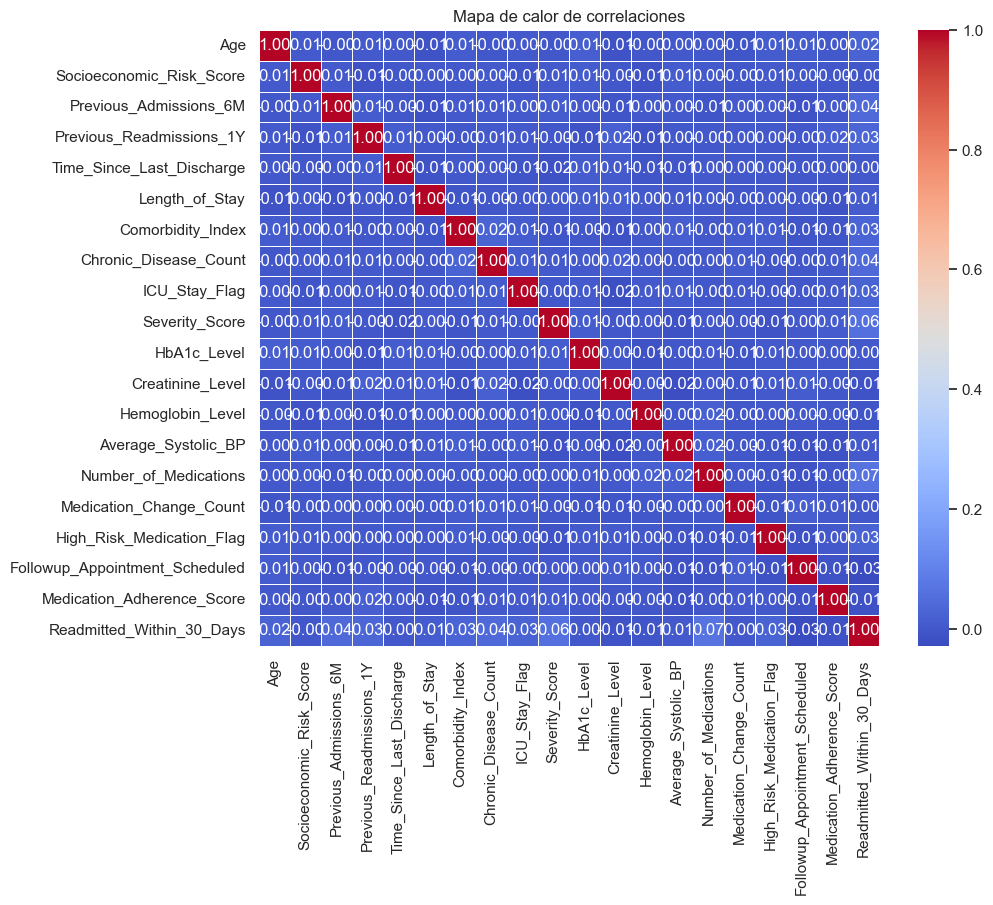

In [24]:
# Mapa de calor de correlaciones entre variables numéricas
plt.figure(figsize=(10, 8))

correlacion = df.select_dtypes(include=np.number).corr()

sns.heatmap(
    correlacion,
    annot=True,
    cmap="coolwarm",
    fmt=".2f",
    linewidths=0.5
)

plt.title("Mapa de calor de correlaciones")
plt.show()

El mapa de calor permite revisar la relación entre las variables numéricas. 
En este dataset, las correlaciones lineales con la variable objetivo no son muy altas. 
Esto significa que la readmisión hospitalaria probablemente no depende de una sola variable, sino de la combinación de varios factores clínicos, demográficos y administrativos.

Las variables con mayor relación positiva con la readmisión son `Number_of_Medications`, `Severity_Score`, `Previous_Admissions_6M`, `Chronic_Disease_Count` y `Previous_Readmissions_1Y`.

### **Análisis específico del dataset**

#### **Tasa de Readmisión según Tipo de Admisión**

In [25]:
# Calculamos la tasa de readmisión según tipo de admisión
readmision_admission = df.groupby("Admission_Type")["Readmitted_Within_30_Days"].mean() * 100
readmision_admission = readmision_admission.sort_values(ascending=False)

readmision_admission

Admission_Type
Urgent       74.564749
Elective     74.431438
Emergency    73.484722
Name: Readmitted_Within_30_Days, dtype: float64

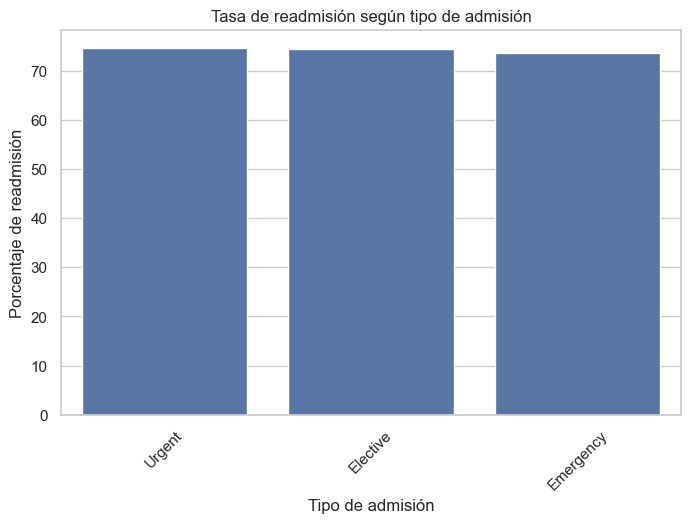

In [26]:
plt.figure(figsize=(8, 5))

sns.barplot(
    x=readmision_admission.index,
    y=readmision_admission.values
)

plt.title("Tasa de readmisión según tipo de admisión")
plt.xlabel("Tipo de admisión")
plt.ylabel("Porcentaje de readmisión")
plt.xticks(rotation=45)
plt.show()

La tasa de readmisión es levemente mayor en pacientes con admisión urgente. 
Sin embargo, las diferencias entre los tipos de admisión no son extremadamente marcadas, por lo que esta variable por sí sola no explica completamente el riesgo de readmisión.

#### **Tasa de Readmisión según Diagnóstico Principal**

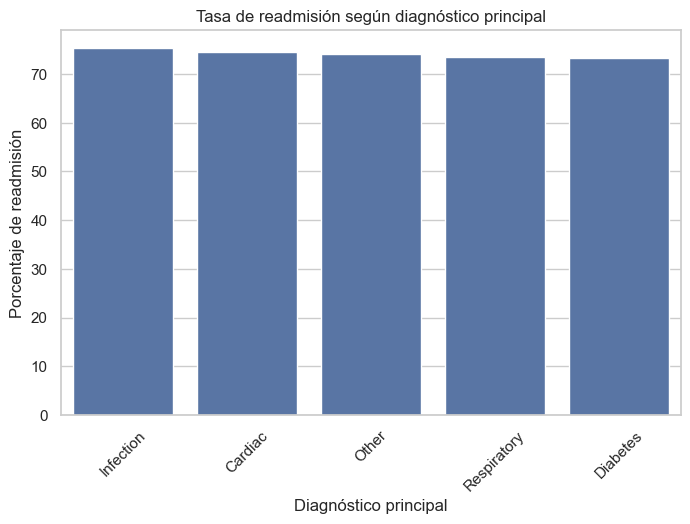

In [27]:
# Calculamos la tasa de readmisión según diagnóstico principal
readmision_diagnostico = df.groupby("Primary_Diagnosis_Group")["Readmitted_Within_30_Days"].mean() * 100
readmision_diagnostico = readmision_diagnostico.sort_values(ascending=False)

readmision_diagnostico

plt.figure(figsize=(8, 5))

sns.barplot(
    x=readmision_diagnostico.index,
    y=readmision_diagnostico.values
)

plt.title("Tasa de readmisión según diagnóstico principal")
plt.xlabel("Diagnóstico principal")
plt.ylabel("Porcentaje de readmisión")
plt.xticks(rotation=45)
plt.show()

El grupo diagnóstico con mayor tasa de readmisión es `Infection`, seguido por `Cardiac`. 
Esto puede sugerir que ciertos diagnósticos principales están asociados a mayor probabilidad de volver al hospital dentro de 30 días.

#### **Tasa de Readmisión según Tipo de Seguro**

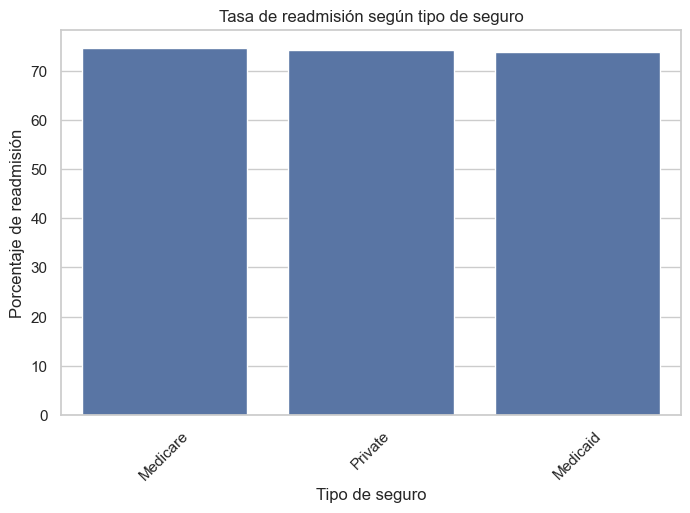

In [28]:
# Calculamos la tasa de readmisión según tipo de seguro
readmision_seguro = df.groupby("Insurance_Type")["Readmitted_Within_30_Days"].mean() * 100
readmision_seguro = readmision_seguro.sort_values(ascending=False)

readmision_seguro
plt.figure(figsize=(8, 5))

sns.barplot(
    x=readmision_seguro.index,
    y=readmision_seguro.values
)

plt.title("Tasa de readmisión según tipo de seguro")
plt.xlabel("Tipo de seguro")
plt.ylabel("Porcentaje de readmisión")
plt.xticks(rotation=45)
plt.show()

La tasa de readmisión según tipo de seguro es relativamente similar entre las categorías. 
Medicare presenta una tasa levemente mayor, pero la diferencia no parece ser suficientemente grande como para explicar por sí sola el fenómeno de readmisión.

#### **Tasa de Readmisión según Disposición al Alta**

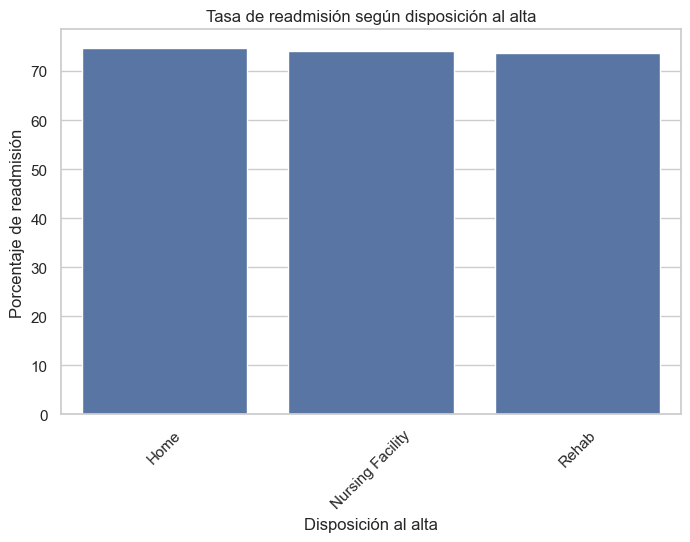

In [29]:
# Calculamos la tasa de readmisión según disposición al alta
readmision_alta = df.groupby("Discharge_Disposition")["Readmitted_Within_30_Days"].mean() * 100
readmision_alta = readmision_alta.sort_values(ascending=False)

readmision_alta
plt.figure(figsize=(8, 5))

sns.barplot(
    x=readmision_alta.index,
    y=readmision_alta.values
)

plt.title("Tasa de readmisión según disposición al alta")
plt.xlabel("Disposición al alta")
plt.ylabel("Porcentaje de readmisión")
plt.xticks(rotation=45)
plt.show()

La tasa de readmisión es levemente mayor en pacientes dados de alta a su hogar. 
Sin embargo, las diferencias con las otras categorías son pequeñas, por lo que esta variable debe analizarse en conjunto con otros factores clínicos.

#### **Comparación de Promedios según Readmisión**

In [30]:
# Promedios de variables numéricas según la variable objetivo
df.groupby("Readmitted_Within_30_Days")[columnas_numericas].mean().round(2)

,Age,Socioeconomic_Risk_Score,Previous_Admissions_6M,Previous_Readmissions_1Y,Time_Since_Last_Discharge,Length_of_Stay,Comorbidity_Index,Chronic_Disease_Count,ICU_Stay_Flag,Severity_Score,HbA1c_Level,Creatinine_Level,Hemoglobin_Level,Average_Systolic_BP,Number_of_Medications,Medication_Change_Count,High_Risk_Medication_Flag,Followup_Appointment_Scheduled,Medication_Adherence_Score,Readmitted_Within_30_Days
Readmitted_Within_30_Days,,,,,,,,,,,,,,,,,,,,
0,53.67,5.02,1.41,0.94,90.19,9.95,2.39,1.89,0.18,4.75,7.0,1.21,13.03,139.10,7.04,2.00,0.28,0.72,0.71,0.0
1,54.79,5.00,1.54,1.02,90.26,10.08,2.51,2.03,0.20,5.10,7.0,1.20,13.00,139.47,7.65,2.01,0.31,0.69,0.70,1.0


Al comparar los promedios según la variable objetivo, se observan algunas diferencias entre pacientes readmitidos y no readmitidos.

Los pacientes readmitidos tienden a presentar un mayor número de medicamentos, mayor puntaje de severidad, más admisiones previas, más enfermedades crónicas y más readmisiones anteriores. 
Aunque las diferencias no son extremadamente grandes, estas variables pueden aportar información relevante para un futuro modelo predictivo.
| Variable                     | No readmitido | Readmitido | Interpretación                        |
| ---------------------------- | ------------: | ---------: | ------------------------------------- |
| `Age`                        |         53.67 |      54.79 | Readmitidos son levemente mayores     |
| `Previous_Admissions_6M`     |          1.41 |       1.54 | Más admisiones previas en readmitidos |
| `Previous_Readmissions_1Y`   |          0.94 |       1.02 | Más readmisiones previas              |
| `Severity_Score`             |          4.75 |       5.10 | Mayor severidad en readmitidos        |
| `Chronic_Disease_Count`      |          1.89 |       2.03 | Más enfermedades crónicas             |
| `Number_of_Medications`      |          7.04 |       7.65 | Más medicamentos en readmitidos       |
| `Medication_Adherence_Score` |          0.71 |       0.70 | Levemente menor adherencia            |


## **Principales gráficos** 

#### **Distribución de la variable objetivo**

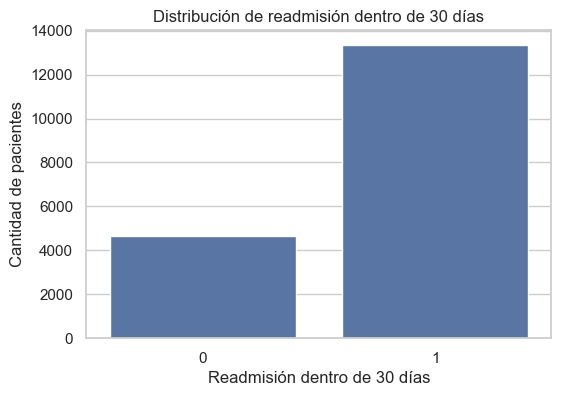

In [31]:

plt.figure(figsize=(6, 4))

sns.countplot(
    data=df,
    x="Readmitted_Within_30_Days"
)

plt.title("Distribución de readmisión dentro de 30 días")
plt.xlabel("Readmisión dentro de 30 días")
plt.ylabel("Cantidad de pacientes")
plt.show()

#### **Boxplot de número de medicamentos según readmisión**

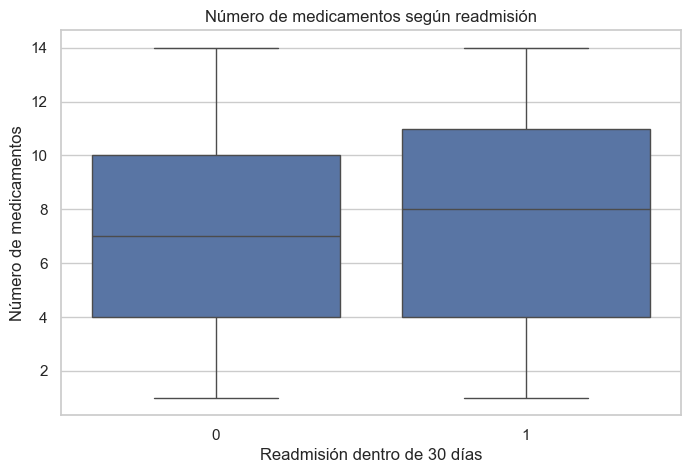

In [32]:
plt.figure(figsize=(8, 5))

sns.boxplot(
    data=df,
    x="Readmitted_Within_30_Days",
    y="Number_of_Medications"
)

plt.title("Número de medicamentos según readmisión")
plt.xlabel("Readmisión dentro de 30 días")
plt.ylabel("Número de medicamentos")
plt.show()

#### **Boxplot de puntaje de severidad según readmisión**

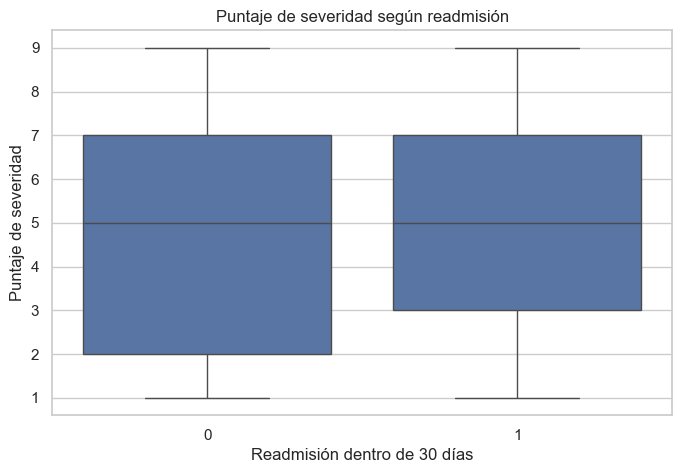

In [33]:
plt.figure(figsize=(8, 5))

sns.boxplot(
    data=df,
    x="Readmitted_Within_30_Days",
    y="Severity_Score"
)

plt.title("Puntaje de severidad según readmisión")
plt.xlabel("Readmisión dentro de 30 días")
plt.ylabel("Puntaje de severidad")
plt.show()

#### **Tasa de readmisión por diagnóstico principal**

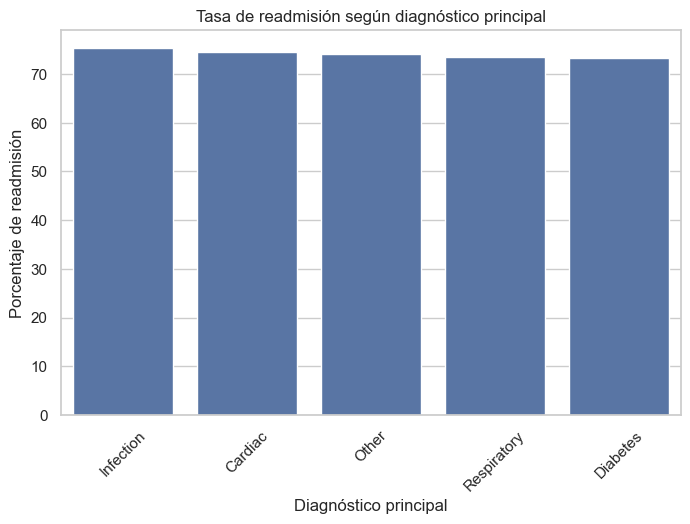

In [34]:
readmision_diagnostico = df.groupby("Primary_Diagnosis_Group")["Readmitted_Within_30_Days"].mean() * 100
readmision_diagnostico = readmision_diagnostico.sort_values(ascending=False)

plt.figure(figsize=(8, 5))

sns.barplot(
    x=readmision_diagnostico.index,
    y=readmision_diagnostico.values
)

plt.title("Tasa de readmisión según diagnóstico principal")
plt.xlabel("Diagnóstico principal")
plt.ylabel("Porcentaje de readmisión")
plt.xticks(rotation=45)
plt.show()

#### **Mapa de calor**

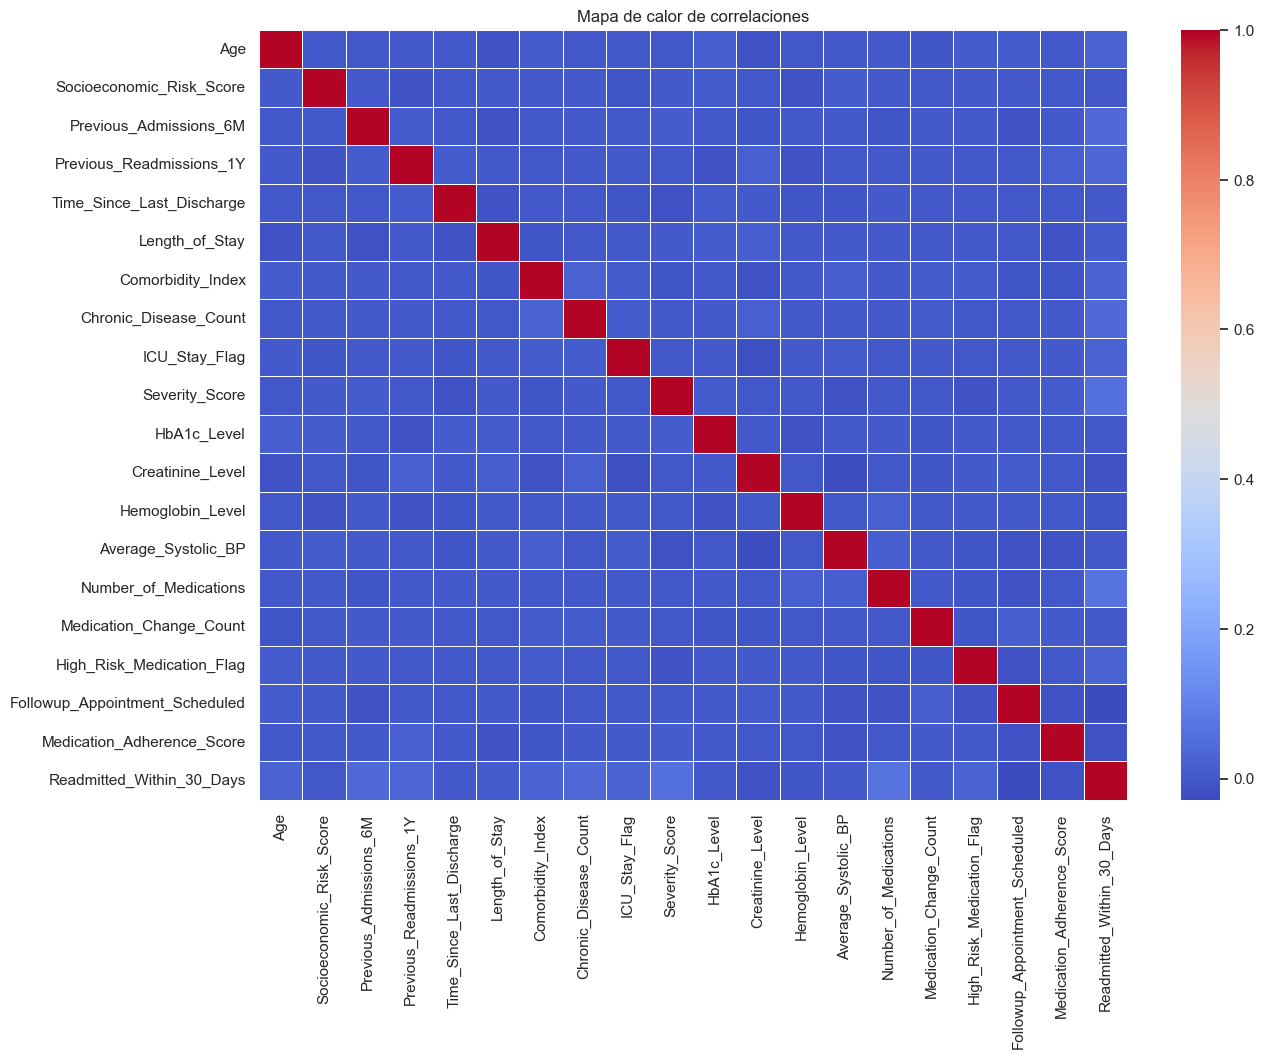

In [35]:
plt.figure(figsize=(14, 10))

correlacion = df.select_dtypes(include=np.number).corr()

sns.heatmap(
    correlacion,
    annot=False,
    cmap="coolwarm",
    linewidths=0.5
)

plt.title("Mapa de calor de correlaciones")
plt.show()

# **Resumen de Hallazgos**

El dataset de readmisión hospitalaria contiene 18.000 registros y 25 variables. Presenta una estructura ordenada, sin valores nulos y sin registros duplicados, lo cual facilita el análisis inicial.

La variable objetivo es `Readmitted_Within_30_Days`, que indica si un paciente fue readmitido o no dentro de los 30 días posteriores al alta médica. La distribución de esta variable muestra que aproximadamente el 74,16% de los pacientes fueron readmitidos, mientras que el 25,84% no lo fueron. Esto indica un desbalance de clases que debe considerarse en futuras etapas de modelamiento.

Durante la revisión de variables categóricas no se detectaron incongruencias evidentes. Las categorías de género, tipo de seguro, tipo de admisión, diagnóstico principal y disposición al alta están escritas de forma consistente.

En las variables numéricas se identificaron posibles outliers en `Previous_Admissions_6M`, `Previous_Readmissions_1Y`, `HbA1c_Level`, `Creatinine_Level` y `Hemoglobin_Level`. Estos valores no necesariamente deben eliminarse, ya que pueden representar pacientes con condiciones clínicas más complejas.

El análisis de correlaciones muestra que ninguna variable numérica tiene una relación lineal muy fuerte con la readmisión. Sin embargo, algunas variables presentan una relación positiva leve con la variable objetivo, como `Number_of_Medications`, `Severity_Score`, `Previous_Admissions_6M`, `Chronic_Disease_Count` y `Previous_Readmissions_1Y`.

Además, el análisis por grupos muestra que los pacientes con diagnóstico principal de infección presentan una tasa de readmisión levemente mayor. También se observa que los pacientes readmitidos tienden a tener mayor severidad, más medicamentos, más admisiones previas y más enfermedades crónicas.

En general, el dataset es adecuado para desarrollar un problema de clasificación binaria orientado a predecir el riesgo de readmisión hospitalaria dentro de 30 días.

# **Diagnóstico del Dataset**

El dataset presenta una buena calidad inicial, ya que no contiene valores nulos ni registros duplicados. 
Además, las variables categóricas no muestran errores evidentes de escritura o categorías mal registradas.

Uno de los principales desafíos es el desbalance de la variable objetivo, ya que la mayoría de los pacientes pertenece a la clase 1, es decir, pacientes readmitidos dentro de 30 días. 
Esto puede afectar el entrenamiento de modelos predictivos, porque un modelo podría favorecer la clase mayoritaria.

Otro desafío es la presencia de variables clínicas con posibles outliers. En salud, estos valores pueden representar pacientes más graves, por lo que no deben eliminarse sin análisis previo.

También se observa que las correlaciones lineales con la variable objetivo son bajas. Esto significa que la readmisión hospitalaria probablemente depende de la combinación de varias variables y no de un único factor aislado.

A pesar de estos desafíos, el dataset es muy útil para análisis predictivo, ya que contiene información clínica, demográfica y administrativa relevante para estudiar el riesgo de readmisión hospitalaria.
# **Problemática Seleccionada**

La problemática seleccionada para este dataset es un problema de **clasificación binaria**.

El objetivo será predecir si un paciente será readmitido dentro de los 30 días posteriores al alta médica. 
La variable objetivo será `Readmitted_Within_30_Days`, donde el valor 1 indica que el paciente fue readmitido y el valor 0 indica que no fue readmitido.

Este problema es relevante porque las readmisiones hospitalarias pueden generar altos costos para el sistema de salud y afectar la calidad de vida de los pacientes. 
Un modelo predictivo podría ayudar a identificar pacientes con mayor riesgo y apoyar decisiones preventivas, como seguimiento médico, coordinación de controles o intervención temprana.

# **Justificación de la Elección**


Se elige este dataset porque presenta una problemática clara, relevante y aplicable al área de salud. 
La readmisión hospitalaria dentro de 30 días es un indicador importante para evaluar continuidad del cuidado, calidad de atención y riesgo clínico del paciente.

El dataset es interesante porque combina distintos tipos de variables: demográficas, clínicas, administrativas y relacionadas con medicamentos. 
Esto permite realizar un análisis exploratorio completo y también preparar una futura etapa de modelamiento predictivo.

Además, el dataset presenta desafíos importantes para ciencia de datos, como desbalance de clases, variables categóricas, posibles outliers clínicos y correlaciones individuales bajas con la variable objetivo. 
Estos elementos hacen que el problema sea más desafiante que un dataset demasiado simple.

Por estas razones, este conjunto de datos es una buena opción para desarrollar un problema de clasificación binaria orientado a la predicción del riesgo de readmisión hospitalaria.

# **Conclusión**

El dataset de riesgo de readmisión hospitalaria es una opción sólida para el Proyecto 2, ya que contiene una variable objetivo clara y una problemática relevante dentro del área de salud.

El conjunto de datos está limpio en términos de valores nulos y duplicados, pero presenta desafíos interesantes como desbalance de clases, variables clínicas con posibles outliers y baja correlación lineal entre variables individuales y la readmisión.

Por lo tanto, este dataset puede considerarse de nivel intermedio y es adecuado para trabajar una problemática de clasificación binaria.